In [20]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

Shortest Path: 
A->B->E->G
Total Cost:  8


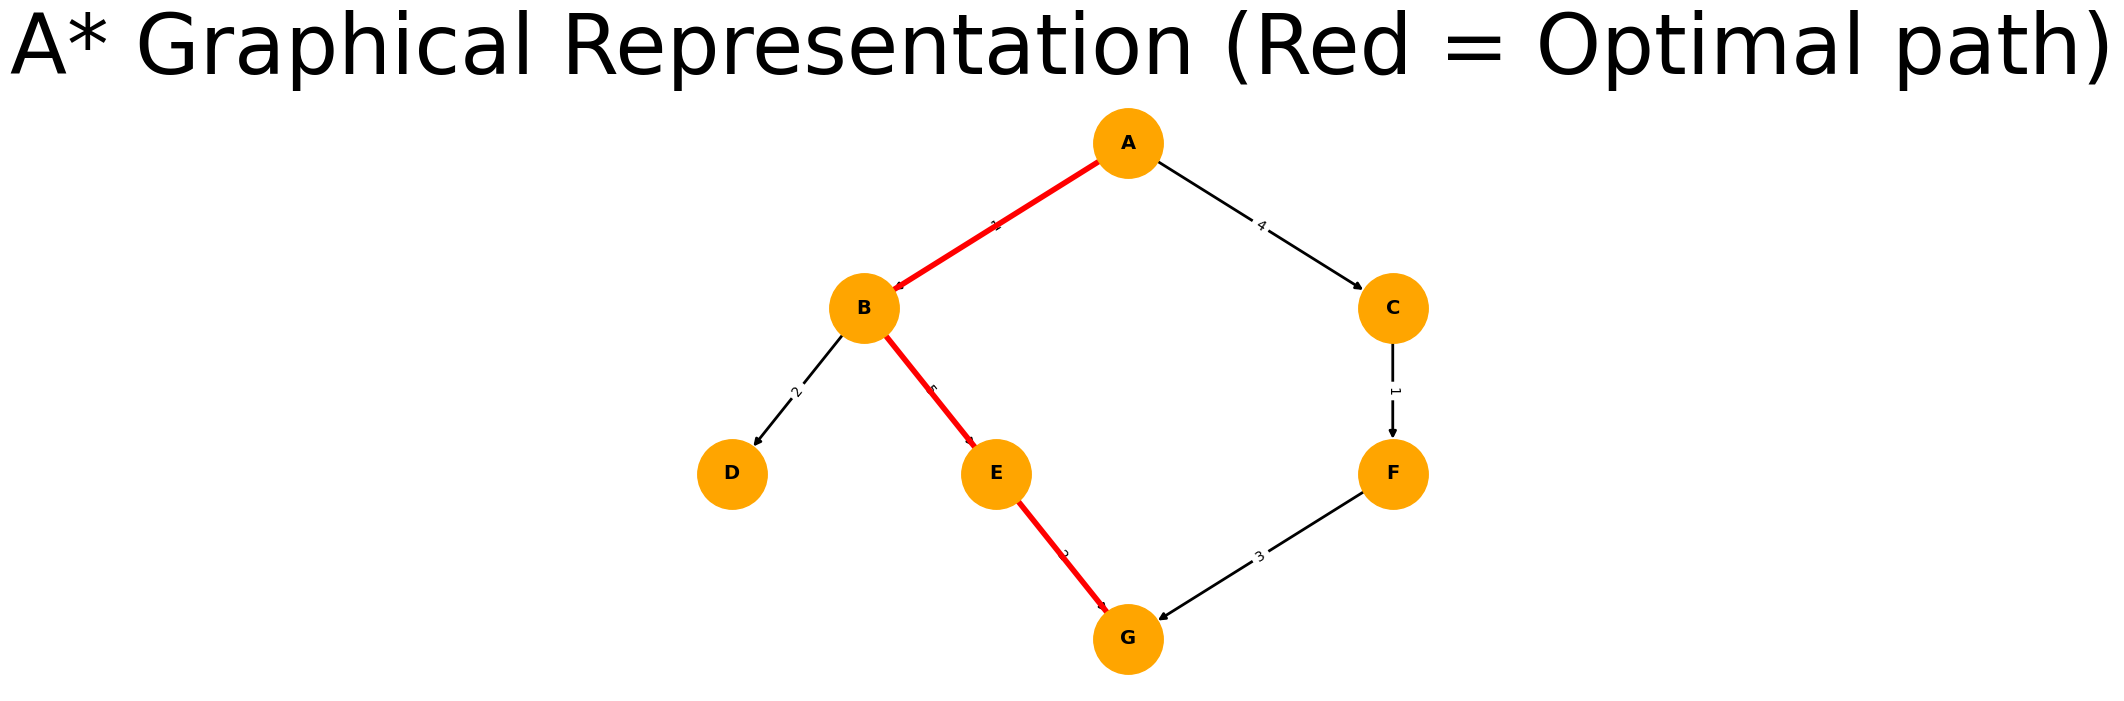

In [3]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt

#Define the graph with edge costs
graph= {
    'A':[('B',1), ('C',4)],
    'B':[('D',2),('E',5)],
    'C':[('F',1)],
    'D':[],
    'E':[('G',2)],
    'F':[('G',3)],
    'G':[]
}

#Heuristic values
heuristic={
    'A':7,
    'B':6,
    'C':2,
    'D':5,
    'E':2,
    'F':1,
    'G':0
}

#A* Algorithm
def astar(graph, heuristic, start, goal):
    pq= [(heuristic[start], 0, start, [start])]
    visited = set()
    while pq:
        f, g, node, path = heapq.heappop(pq)
        if node == goal:
            return path,g
            
        if node in visited:
            continue

        visited.add(node)

        for neighbor, cost in graph[node]:
            new_g = g + cost
            new_f = new_g + heuristic[neighbor]
            heapq.heappush(pq, (new_f, new_g, neighbor, path + [neighbor]))

    return None, float('inf')

# Run A*
path, cost = astar(graph, heuristic, 'A', 'G')

print ("Shortest Path: ")
print ("->".join(path))
print ("Total Cost: ", cost)

G = nx.DiGraph()

#Add edges with weights
for node in graph:
    for neighbor, weight in graph[node]:
        G.add_edge(node, neighbor, weight=weight)

# Positions for visualization
pos = {
    'A' : (0,3),
    'B' : (-1,2),
    'C' : (1,2),
    'D' : (-1.5,1),
    'E' : (-0.5,1),
    'F' : (1,1),
    'G' : (0,0)
}

plt.figure(figsize=(8,6))

# Draw nodes and edges 
nx.draw(
    G, pos,
    with_labels=True,
    node_color='Orange',
    node_size=2500,
    font_size=14,
    font_weight='bold',
    edge_color='black',
    arrows=True,
    width=2
)

# Draw edge labels(costs)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

# Highlight the shortest path
path_edges = list(zip(path[:-1], path[1:]))

nx.draw_networkx_edges(
    G, pos,
    edgelist=path_edges,
    edge_color='red',
    width=4,
    arrows=True
)

plt.title("A* Graphical Representation (Red = Optimal path)",fontsize=60)
plt.axis('off')
plt.show()

Optimal Solution Path:
A -> C -> F
Total Cost = 6


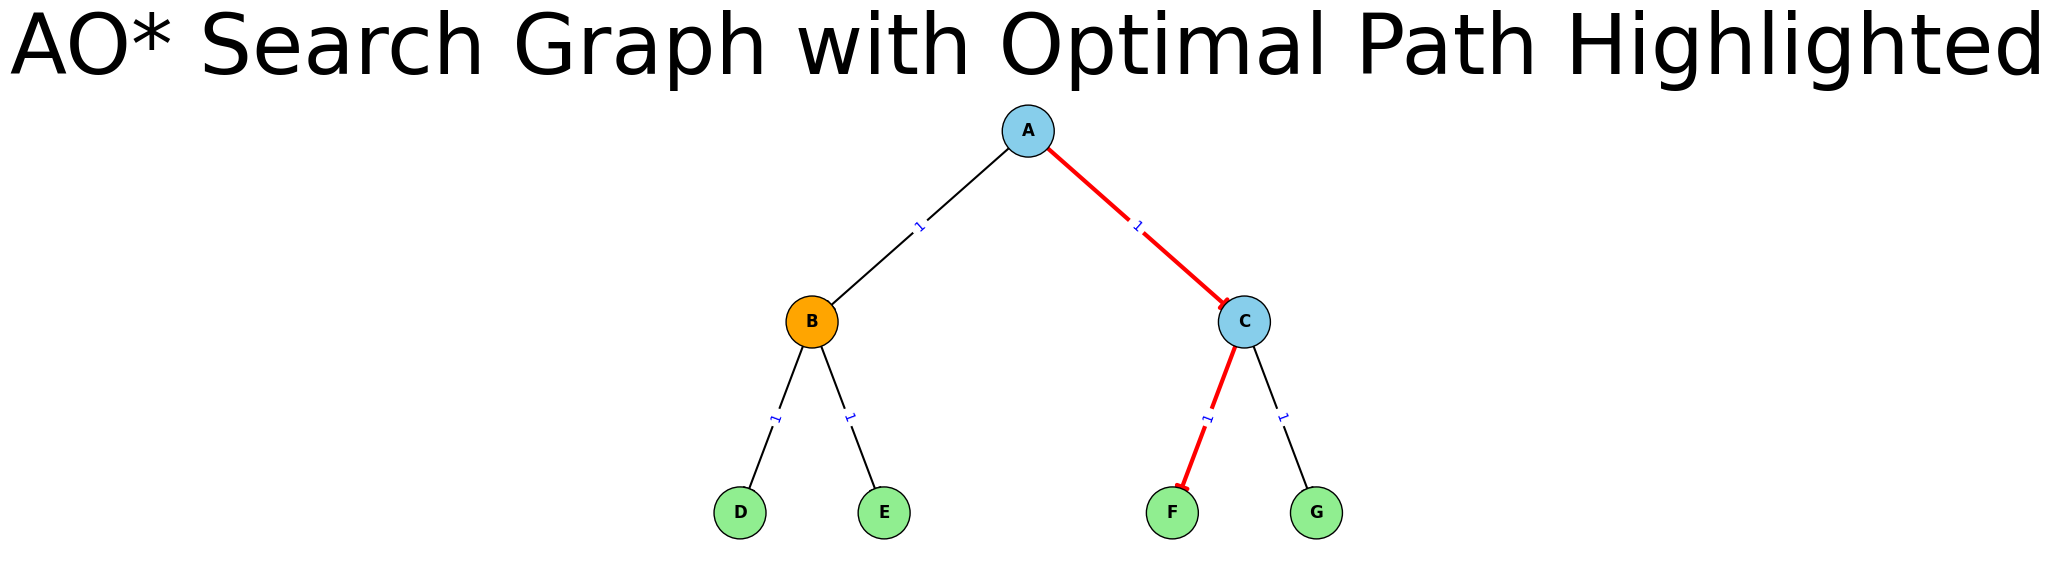

In [4]:
import networkx as nx
import matplotlib.pyplot as plt

# ---------------------------------
# Define the AO* Graph
# ---------------------------------

graph = {
    'A': {'type': 'OR','children': [('B', 1), ('C', 1)]},
    'B': {'type': 'AND','children': [('D', 1), ('E', 1)]},
    'C': {'type': 'OR','children': [('F', 1), ('G', 1)]},
    'D': {'type': 'LEAF','cost': 2},
    'E': {'type': 'LEAF','cost': 3},
    'F': {'type': 'LEAF','cost': 4},
    'G': {'type': 'LEAF','cost': 6}
}

# ---------------------------------
# AO* Algorithm
# ---------------------------------

def ao_star(node):
    info = graph[node]

    # Leaf Node
    if info['type'] == 'LEAF':
        return info['cost'], [node]

    # OR Node
    elif info['type'] == 'OR':
        best_cost = float('inf')
        best_path = []

        for child, edge_cost in info['children']:
            child_cost, child_path = ao_star(child)
            total_cost = edge_cost + child_cost

            if total_cost < best_cost:
                best_cost = total_cost
                best_path = [node] + child_path

        return best_cost, best_path

    # AND Node
    elif info['type'] == 'AND':
        total_cost = 0
        full_path = [node]

        for child, edge_cost in info['children']:
            child_cost, child_path = ao_star(child)
            total_cost += edge_cost + child_cost
            full_path += child_path

        return total_cost, full_path


# ---------------------------------
# Run AO*
# ---------------------------------

cost, path = ao_star('A')

print("Optimal Solution Path:")
print(" -> ".join(path))
print("Total Cost =", cost)

# ---------------------------------
# Create Graph
# ---------------------------------

G = nx.DiGraph()

for node, info in graph.items():
    if 'children' in info:
        for child, weight in info['children']:
            G.add_edge(node, child, weight=weight)

# ---------------------------------
# Node Positions
# ---------------------------------

pos = {
    'A': (0, 3),
    'B': (-1.5, 2),
    'C': (1.5, 2),
    'D': (-2, 1),
    'E': (-1, 1),
    'F': (1, 1),
    'G': (2, 1)
}

# ---------------------------------
# Node Colors
# ---------------------------------

node_colors = []

for node in G.nodes():
    if graph[node]['type'] == 'OR':
        node_colors.append('skyblue')
    elif graph[node]['type'] == 'AND':
        node_colors.append('orange')
    else:
        node_colors.append('lightgreen')

# ---------------------------------
# Highlight Optimal Path
# ---------------------------------

path_edges = list(zip(path[:-1], path[1:]))

edge_colors = []
edge_widths = []

for edge in G.edges():
    if edge in path_edges:
        edge_colors.append('red')      # Optimal path
        edge_widths.append(3)
    else:
        edge_colors.append('black')
        edge_widths.append(1.5)

# ---------------------------------
# Draw Graph
# ---------------------------------

plt.figure(figsize=(9,6))

nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    node_size=1400,
    edgecolors='black'
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=12,
    font_weight='bold'
)

nx.draw_networkx_edges(
    G,
    pos,
    edge_color=edge_colors,
    width=edge_widths,
    arrows=True,
    arrowsize=20
)

edge_labels = nx.get_edge_attributes(G, 'weight')

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_color='blue'
)

plt.title("AO* Search Graph with Optimal Path Highlighted", fontsize=60)
plt.axis('off')
plt.show()